In [9]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict

In [18]:
llm = ChatOllama(model="llama3.2:3b", temperature=0.1)

In [19]:
class LLmState(TypedDict):
    question:str
    answer:str

In [20]:
def LLmQA(state:LLmState) -> LLmState:
    question = state['question']
    prompt = f"Answer the Questions in Depth {question}"
    answer = llm.invoke(prompt).content
    state['answer'] = answer

    return state

In [24]:
graph = StateGraph(LLmState)

graph.add_node("LLmQA",LLmQA)

graph.add_edge(START,"LLmQA")
graph.add_edge("LLmQA",END)

workflow = graph.compile()

In [27]:
initial_state = {"question":"How far is Mars from earth"}
final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'How far is Mars from earth', 'answer': 'The distance between Mars and Earth varies as both planets follow elliptical orbits around the Sun. On average, the distance between Mars and Earth is about 225 million kilometers (139.8 million miles). However, this distance can range from a minimum of approximately 56 million kilometers (34.8 million miles) at its closest approach (known as "opposition") to a maximum of about 401 million kilometers (249.2 million miles) at its farthest point.\n\nTo put this in perspective, consider that the fastest spacecraft ever built, NASA\'s Mars Reconnaissance Orbiter, took about 6.5 months to reach Mars from Earth. The average distance between Mars and Earth is so vast that it takes a spacecraft several months to travel between the two planets.\n\nHere are some key facts about the distance between Mars and Earth:\n\n1. **Average distance**: 225 million kilometers (139.8 million miles)\n2. **Closest approach** (opposition): approximately 56 m

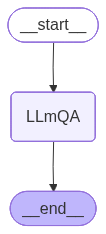

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())